Lowest energy levels:
  E_0 = 0.3927
  E_1 = 1.4971
  E_2 = 2.3664
  E_3 = 3.0804
  E_4 = 3.8744
  E_5 = 4.6450


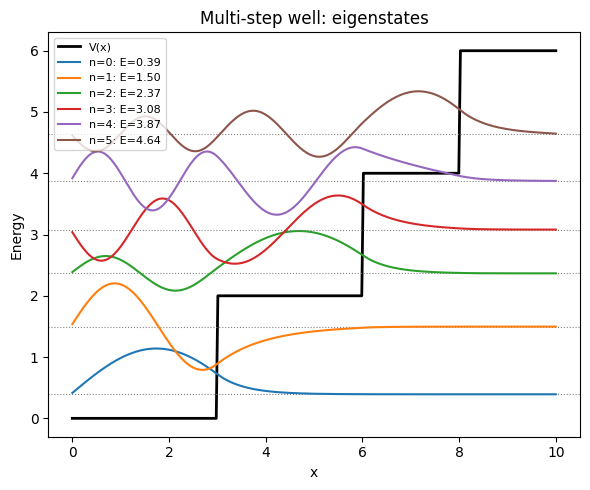

In [1]:
"""
Multi-step potential well with QuTiP
------------------------------------
A particle in a 1D box whose floor rises in steps (a "staircase" well).
We discretize space on a grid, build the Hamiltonian as a QuTiP Qobj,
find its bound states, and evolve a wavepacket in time.

Units: hbar = 1, m = 1
"""
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ---- 1. Spatial grid ------------------------------------------------------
N = 300                      # number of grid points
L = 10.0                     # width of the box (hard walls at both ends)
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# ---- 2. Multi-step potential ---------------------------------------------
# Each tuple is (start, end, height); the well floor rises in three steps.
steps = [(0.0, 3.0, 0.0),
         (3.0, 6.0, 2.0),
         (6.0, 8.0, 4.0),
         (8.0, 10.0, 6.0)]

V = np.zeros(N)
for start, end, height in steps:
    V[(x >= start) & (x < end)] = height
V[-1] = steps[-1][2]

# ---- 3. Hamiltonian H = -1/2 d^2/dx^2 + V(x) ------------------------------
# Finite-difference second derivative (tridiagonal matrix)
kinetic = (np.diag(np.full(N, 2.0))
           - np.diag(np.ones(N - 1), 1)
           - np.diag(np.ones(N - 1), -1)) / (2 * dx**2)

H = qt.Qobj(kinetic + np.diag(V))    # Hamiltonian as a QuTiP operator
x_op = qt.Qobj(np.diag(x))           # position operator

# ---- 4. Eigenstates -------------------------------------------------------
n_states = 6
energies, kets = H.eigenstates(eigvals=n_states)

print("Lowest energy levels:")
for n, E in enumerate(energies):
    print(f"  E_{n} = {E:.4f}")

# ---- 5. Time evolution of a Gaussian wavepacket ---------------------------
x0, sigma, k0 = 1.5, 0.5, 3.0        # start in the low region, moving right
psi_x = np.exp(-(x - x0)**2 / (2 * sigma**2)) * np.exp(1j * k0 * x)
psi0 = qt.Qobj(psi_x.reshape(-1, 1)).unit()

tlist = np.linspace(0, 8, 400)
result = qt.sesolve(H, psi0, tlist, e_ops=[x_op])
mean_x = result.expect[0]

# ---- 6. Plots -------------------------------------------------------------
#fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))
fig, (ax1) = plt.subplots(1,1, figsize=(6, 5))
# Potential with wavefunctions drawn at their energy levels
ax1.plot(x, V, "k", lw=2, label="V(x)")
scale = 1.0
for n, (E, ket) in enumerate(zip(energies, kets)):
    psi = ket.full().flatten().real / np.sqrt(dx)   # normalized psi(x)
    ax1.axhline(E, color="gray", ls=":", lw=0.8)
    ax1.plot(x, E + scale * psi, label=f"n={n}: E={E:.2f}")
ax1.set_xlabel("x")
ax1.set_ylabel("Energy")
ax1.set_title("Multi-step well: eigenstates")
ax1.legend(fontsize=8, loc="upper left")

# Expectation value of position over time
#ax2.plot(tlist, mean_x)
#ax2.set_xlabel("time")
#ax2.set_ylabel("<x>")
#ax2.set_title("Wavepacket <x>(t)")
#for start, _, _ in steps[1:]:
#    ax2.axhline(start, color="gray", ls="--", lw=0.8)   # step edges

plt.tight_layout()
plt.show()

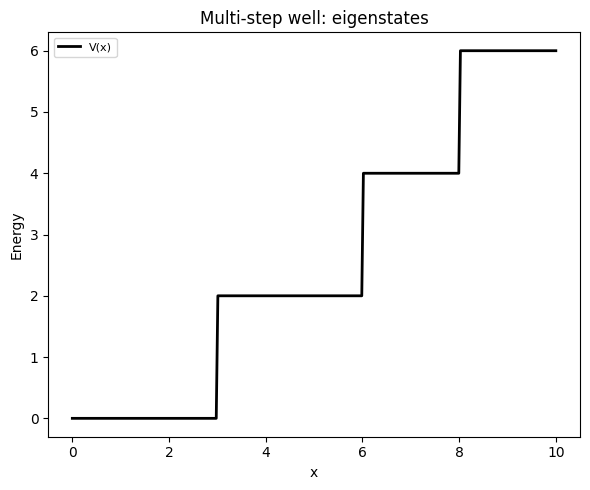

In [9]:
# ---- Before-solution figure: potential only ----
fig0, ax0 = plt.subplots(figsize=(6, 5))   # same size as one panel of the final figure
ax0.plot(x, V, "k", lw=2, label="V(x)")
ax0.set_xlabel("x")
ax0.set_ylabel("Energy")
ax0.set_title("Multi-step well: eigenstates")
ax0.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()   # close this window to continue to the solutions